In [156]:
import torch
import nn4n

In [157]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

N, C = 512, 100
model_cfg = {
            "input_dim":    C,
            "hidden_dim":   N,
            'output_dim':   C,
            "alpha":        0.01,
            "learn_alpha":  False,
            "preact_noise": 0.,
            "postact_noise":0.
            }


rnn = nn4n.nn.RNN(
      # Input laters (multiple recurrent layers)
      recurrent_layers=[# 1st recurrent layer
                        nn4n.nn.RecurrentLayer(
                        projection_layer=nn4n.nn.LinearLayer(
                                         input_dim=model_cfg["input_dim"],
                                         output_dim=model_cfg["hidden_dim"]
                                         ),
                        leaky_layer=nn4n.nn.LeakyLinearLayer(
                                    # input_dim=model_cfg["hidden_dim"],
                                    # output_dim=model_cfg["hidden_dim"],
                                    # ----------------------------------------
                                    linear_layer=nn4n.nn.LinearLayer(
                                        input_dim=model_cfg["hidden_dim"],
                                        output_dim=model_cfg["hidden_dim"]),
                                    # ----------------------------------------
                                    activation=torch.nn.ReLU(),
                                    alpha=model_cfg["alpha"],
                                    learn_alpha=model_cfg["learn_alpha"],
                                    preact_noise=model_cfg["preact_noise"],
                                    postact_noise=model_cfg["postact_noise"]
                                    )
                        )
                        # 2nd recurrent layer (None)
                        ],
      # Output layer
      readout_layer=nn4n.nn.LinearLayer(
                    input_dim=model_cfg["hidden_dim"],
                    output_dim=model_cfg["output_dim"]
                    )
      )
rnn.to(device)

optimizer = torch.optim.Adam(rnn.parameters(), lr=0.0005) 

Using device: cuda


In [149]:
import numpy as np
load_data_type = '2TS_1_data'

data = np.load(f'../time_exp/{load_data_type}.npy', allow_pickle=True).item()
test_inputs = data['test_inputs']
print(test_inputs.shape)

torch.Size([7, 200, 100])


In [150]:
# Load model weights 
model_dict = torch.load(f'../time_exp/2TS_1_rnn.pth', map_location=torch.device('cuda'))

Wrc_trained = model_dict['recurrent_layers.0.leaky_layer.linear_layer.weight'].cpu().numpy()
trained_brc = model_dict['recurrent_layers.0.leaky_layer.linear_layer.bias'].cpu().numpy()

Win_trained = model_dict['readout_layer.weight'].cpu().numpy()
trained_bin = model_dict['readout_layer.bias'].cpu().numpy()

Wout_trained = model_dict['recurrent_layers.0.projection_layer.weight'].cpu().numpy()
trained_bout = model_dict['recurrent_layers.0.projection_layer.bias'].cpu().numpy()    

## Construct $W_{rc}$

In [241]:
# # Create a recurrent weight matrix
# Wrc = np.zeros((N,N))
# # # Assign negative weights to all elements of Wrc
# # Wrc = np.random.normal(loc=-0.003, scale=0.001, size=(N, N))
# # Initiate the diagonal elements
# diags = np.random.normal(loc=-0.15, scale=0.02, size=(N)) 
# Delta, gain, loss = 200, 0.002, 0.001
# # Set up limits for each row
# limits1 = np.linspace(Delta, 0, N, dtype=int)
# limits2 = np.linspace(0, Delta, N, dtype=int)
# for i in range(N):
#     Wrc[i,i] = diags[i]
#     for j in range(N):
#         if j > i and j < (i + limits1[i]):
#             Wrc[i,j] = (j-i) * gain
#         if j < i and j > (i - limits2[i]):
#             Wrc[i,j] = (j-i) * loss
    
# # Plot the Wrc matrix
# from matplotlib import pyplot as plt
# plt.figure(figsize=(4,3.5))
# # Set colorbar symmetric around zero
# plt.imshow(Wrc, cmap='coolwarm', vmin=-0.3, vmax=0.3)
# plt.colorbar(label='Weight value')
# plt.xlabel('Neuron index')
# plt.ylabel('Neuron index')
# plt.tight_layout()

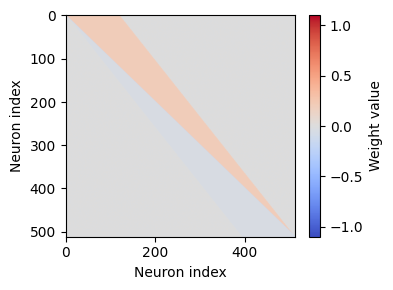

In [240]:
# Create a recurrent weight matrix
Wrc = np.zeros((N,N))
# Assign negative weights to all elements of Wrc
Wrc = np.random.normal(loc=-0.0025, scale=0.01, size=(N, N))
# Initiate the diagonal elements
diags = np.random.normal(loc=-0.15, scale=0.02, size=(N)) 
Delta, gain, loss = 120, 0.2, -0.05
# Set up limits for each row
limits1 = np.linspace(Delta, 0, N, dtype=int)
limits2 = np.linspace(0, Delta, N, dtype=int)
for i in range(N):
    Wrc[i,i] = diags[i]
    for j in range(N):
        if j > i and j < (i + limits1[i]):
            # Wrc[i,j] = (Delta+i-j) * gain
            Wrc[i,j] = gain
        if j < i and j > (i - limits2[i]):
            # Wrc[i,j] = (Delta-i+j) * loss
            Wrc[i,j] = loss
    
# Plot the Wrc matrix
from matplotlib import pyplot as plt
plt.figure(figsize=(4, 3))
# Set colorbar symmetric around zero
plt.imshow(Wrc, cmap='coolwarm', vmax=1.1, vmin=-1.1, aspect='auto')
plt.colorbar(label='Weight value')
plt.xlabel('Neuron index')
plt.ylabel('Neuron index')
plt.tight_layout()

plt.savefig('Wrc_theory.png', transparent=True, dpi=500)

np.save('Wrc_theory.npy', Wrc)

In [220]:
# ------------------------------ Modify the idealised weights ------------------------------
model_dict['recurrent_layers.0.leaky_layer.linear_layer.weight'] = torch.from_numpy(Wrc.astype(np.float32)).to(device)
# ideal_Wrc = np.load('Wrc_theory.npy')
# model_dict['recurrent_layers.0.leaky_layer.linear_layer.weight'] = torch.from_numpy(ideal_Wrc.astype(np.float32)).to(device)

# # Change the initialization of input weights
# model_dict['recurrent_layers.0.projection_layer.weight'] = torch.from_numpy(np.random.uniform(-np.sqrt(1/C), np.sqrt(1/C), size=(N, C)).astype(np.float32)).to(device)
# model_dict['recurrent_layers.0.projection_layer.weight'] = torch.from_numpy(np.random.uniform(-np.sqrt(1/C), np.sqrt(1/C), size=(N, C)).astype(np.float32)).to(device)

# trained_bin = model_dict['recurrent_layers.0.projection_layer.bias'].cpu().numpy()

In [221]:
rnn.load_state_dict(model_dict)
rnn.eval()
with torch.no_grad():
    test_outputs_from_RNN, hidden_states_from_RNN = rnn(test_inputs)
test_outputs = test_outputs_from_RNN.cpu().numpy()
hidden_states = hidden_states_from_RNN[0].cpu().numpy()
avg_fr = np.mean(hidden_states, axis=0)

(200, 334)


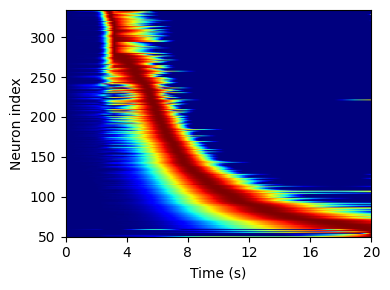

In [235]:
from matplotlib import pyplot as plt
import sys, os
sys.path.insert(0, os.path.abspath('..'))
from func import plt_hs

fig, ax = plt.subplots(figsize=(4,3))
# # Sort avg fr based on the time of peak firing
# avg_fr_sorted = avg_fr[:, np.argsort(np.argmax(avg_fr, axis=0))]
# # Normalise avg_fr for better visualization
# for n in range(avg_fr_sorted.shape[1]):
#     if np.max(avg_fr_sorted[:, n]) - np.min(avg_fr_sorted[:, n]) == 0:
#         avg_fr_sorted[:, n] = 0
#     else:
#         avg_fr_sorted[:, n] = (avg_fr_sorted[:, n] - np.min(avg_fr_sorted[:, n])) / (np.max(avg_fr_sorted[:, n]) - np.min(avg_fr_sorted[:, n]))
# ax.imshow(avg_fr_sorted.T, aspect='auto', cmap='jet', extent=(0, avg_fr_sorted.shape[0]/10, 0, N))
norm_hs, fig, ax = plt_hs(avg_fr, ax=ax, fig=fig, min_fr=0.1)
print(norm_hs.shape)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Neuron index')
ax.set_ylim(50, norm_hs.shape[1])
plt.tight_layout()

vis_idx = np.arange(50, norm_hs.shape[1])
vis_hs = norm_hs[:, vis_idx]
plt.savefig(f'theory_rnn_{load_data_type}_{N}_hs.png', transparent=True, dpi=300, bbox_inches='tight')

In [236]:
# Sort the norm_hs with maximum firing time
max_time_pts = np.argmax(vis_hs, axis=0)

threshold = 0.5
delta = 0.1

# For regions left to the max time pts, find the index where the firing rate is closest to 0.5 and between 0.6 and 0.4
firing_starts = np.zeros(vis_hs.shape[1])
for i in range(vis_hs.shape[1]):
    left_half = vis_hs[:max_time_pts[i], i]
    if np.any((left_half > threshold-delta) & (left_half < threshold+delta)):
        firing_starts[i] = np.where((left_half > threshold-delta) & (left_half < threshold+delta))[0][-1]
        
    else:
        firing_starts[i] = np.nan

# For regions right to the max time pts, find the index where the firing rate is closest to 0.5 and between 0.6 and 0.4
firing_ends = np.zeros(vis_hs.shape[1])
for i in range(vis_hs.shape[1]):
    right_half = vis_hs[max_time_pts[i]:, i]
    if np.any((right_half > threshold-delta) & (right_half < threshold+delta)):
        firing_ends[i] = max_time_pts[i] + np.where((right_half > threshold-delta) & (right_half < threshold+delta))[0][0]
    else:
        firing_ends[i] = np.nan

firing_widths = firing_ends - firing_starts

# Change the unit to time (s)
max_time_pts = max_time_pts / 10
firing_starts = firing_starts / 10
firing_ends = firing_ends / 10
firing_widths = firing_widths / 10

Fitted gradient: 0.5635
Correlation coefficient: 0.8764337883308078


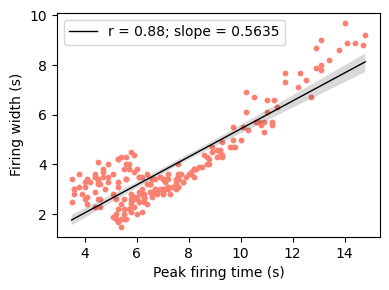

In [239]:
# Plot the firing widths vs the maximum firing times
fig, ax = plt.subplots(figsize=(4,3))

time_start = 3.5
time_critical = 16 # inputs.shape[1]*(sensory_profile['time']['event_onset'][1]) / 10

plt.scatter(max_time_pts[(time_start <= max_time_pts) & (max_time_pts < time_critical)], 
            firing_widths[(time_start <= max_time_pts) & (max_time_pts < time_critical)], c='salmon', s=10)
plt.scatter(max_time_pts[(time_start <= max_time_pts) & (max_time_pts > time_critical)], 
            firing_widths[(time_start <= max_time_pts) & (max_time_pts > time_critical)], c='skyblue', s=10)

# Plot where not nan firing widths
not_nan_mask = ~np.isnan(firing_widths)
max_time_pts = max_time_pts[not_nan_mask]
firing_widths = firing_widths[not_nan_mask]
firing_starts = firing_starts[not_nan_mask]
firing_ends = firing_ends[not_nan_mask]
vis_hs = vis_hs[:, not_nan_mask]

from func import plt_corr
plt_corr(max_time_pts[(time_start <= max_time_pts) & (max_time_pts < time_critical)], 
         firing_widths[(time_start <= max_time_pts) & (max_time_pts < time_critical)], fig=fig, ax=ax)
# plt.ylim(0, 6)
# plt.xlim(2.5, 16)
plt.xlabel('Peak firing time (s)')
plt.ylabel("Firing width (s)")
plt.tight_layout()
plt.legend()
plt.savefig('time_exp_temp_corr.png', dpi=500, transparent=True, bbox_inches='tight')

## Structural analysis

In [2]:
# Load Wrc_theory
import numpy as np
Wrc_theory = np.load('Wrc_theory.npy')

In [ ]:
# Frobenius norm of their difference
diff = Wrc_trained - Wrc_theory
d_F = np.linalg.norm(diff, ord='fro')  
d_F_norm = d_F / np.linalg.norm(Wrc_theory, ord='fro')
print(d_F_norm)

In [ ]:
v_trained = Wrc_trained.ravel()
v_theory  = Wrc_theory.ravel()

# cosine similarity
cos_sim = np.dot(v_trained, v_theory) / (
    np.linalg.norm(v_trained) * np.linalg.norm(v_theory)
)

print("Cosine similarity:", cos_sim)

In [4]:
# Load Wrc_space
model_dict = torch.load(f'../space_exp/square_room_rnn.pth', map_location=torch.device('cuda'))
Wrc_space = model_dict['recurrent_layers.0.leaky_layer.linear_layer.weight'].cpu().numpy()

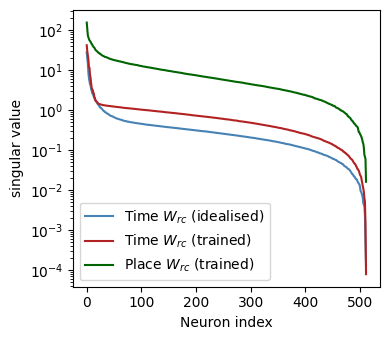

Singular values correlation (time): 0.9912868211218813
Singular values correlation (space): 0.8730551223250675
Normalized distance between singular value spectra (time): 0.6196635252256085
Normalized distance between singular value spectra (space): 0.8401925


In [7]:
from matplotlib import pyplot as plt

U_tr, S_tr, Vt_tr = np.linalg.svd(Wrc_trained, full_matrices=False)
U_th, S_th, Vt_th = np.linalg.svd(Wrc_theory,  full_matrices=False)
U_sp, S_sp, Vt_sp = np.linalg.svd(Wrc_space,  full_matrices=False)

plt.figure(figsize=(4, 3.5))
plt.plot(S_th, color='steelblue', label=r'Time $W_{rc}$ (idealised)')
plt.plot(S_tr, color='firebrick', label=r'Time $W_{rc}$ (trained)')
plt.plot(S_sp, color='darkgreen', label=r'Place $W_{rc}$ (trained)')
plt.xlabel('Neuron index')
plt.ylabel('singular value')
plt.yscale('log')    
plt.legend()
plt.tight_layout()
plt.savefig('singular_values_comparison.png', transparent=True, dpi=500)
plt.show()

corr_S = np.corrcoef(S_tr, S_th)[0, 1]
corr_Sp = np.corrcoef(S_tr, S_sp)[0, 1]
print("Singular values correlation (time):", corr_S)
print("Singular values correlation (space):", corr_Sp)

# Calculate the distance between the singlar value spectra
diff_S_th = S_tr - S_th
diff_S_sp = S_tr - S_sp
norm_diff_S_th = np.linalg.norm(diff_S_th) / np.linalg.norm(S_th)
norm_diff_S_sp = np.linalg.norm(diff_S_sp) / np.linalg.norm(S_sp)
print("Normalized distance between singular value spectra (time):", norm_diff_S_th)
print("Normalized distance between singular value spectra (space):", norm_diff_S_sp)

In [8]:
def principal_angles(U, V):
    # U, V are (N, k) orthonormal basis matrices
    C = U.T @ V
    _, S, _ = np.linalg.svd(C)   # singular values = cos(theta_i)
    return S

# Example with your matrices:
# After SVD:
# U_tr, S_tr, Vt_tr
# U_th, S_th, Vt_th
# U_sp, S_sp, Vt_sp

k = 20
U_tr_k = U_tr[:, :k]
U_th_k = U_th[:, :k]
U_sp_k = U_sp[:, :k]

# compute principal angles (rotation-invariant)
sing_vals = principal_angles(U_tr_k, U_th_k)
sing_vals_sp = principal_angles(U_tr_k, U_sp_k)

print("cos(principal angles):", sing_vals)
print("principal angles (deg):", np.degrees(np.arccos(sing_vals)))

print("cos(principal angles) (space):", sing_vals_sp)
print("principal angles (deg) (space):", np.degrees(np.arccos(sing_vals_sp)))   

cos(principal angles): [0.49098405 0.30829409 0.27753579 0.26999373 0.25472101 0.24443696
 0.22689678 0.21252292 0.20480628 0.16935491 0.16038749 0.14964842
 0.11705997 0.11111767 0.09395703 0.07586979 0.05668269 0.04718474
 0.03098913 0.01472116]
principal angles (deg): [60.59471933 72.04354555 73.88681191 74.33610612 75.24294581 75.85143757
 76.8855595  77.72975687 78.18184061 80.24968554 80.77061184 81.39344746
 83.2775449  83.62025193 84.60870656 85.64879986 86.75057964 87.2955095
 88.22416952 89.15650938]
cos(principal angles) (space): [7.3238128e-01 3.8535273e-01 3.6765674e-01 3.1393412e-01 2.5891641e-01
 2.5334710e-01 2.1904346e-01 1.9332813e-01 1.8680939e-01 1.7948684e-01
 1.5573204e-01 1.4359099e-01 1.3891686e-01 1.0599512e-01 8.3263293e-02
 5.9398051e-02 5.5845533e-02 3.3979330e-02 9.1123795e-03 7.2700228e-04]
principal angles (deg) (space): [42.913597 67.33436  68.42882  71.703514 74.994225 75.32433  77.34714
 78.85293  79.23335  79.660126 81.04074  81.7443   82.01482  83.91

In [51]:
from scipy.linalg import orthogonal_procrustes

R, scale = orthogonal_procrustes(U_tr_k, U_th_k)
U_tr_aligned = U_tr_k @ R

R_sp, scale_sp = orthogonal_procrustes(U_tr_k, U_sp_k)
U_tr_aligned_sp = U_tr_k @ R_sp

# now compare aligned basis
overlap_aligned = np.abs(np.diag(U_tr_aligned.T @ U_th_k))
print("Aligned diagonal overlaps:", overlap_aligned)

overlap_aligned_sp = np.abs(np.diag(U_tr_aligned_sp.T @ U_sp_k))
print("Aligned diagonal overlaps (space):", overlap_aligned_sp)

Aligned diagonal overlaps: [0.43641095 0.14999245 0.19017454 0.15210485 0.15233283 0.19020368
 0.18291015 0.12122646 0.20531025 0.17413605 0.16807727 0.13402933
 0.20947568 0.16557337 0.15645945 0.18737732 0.1376856  0.16168053
 0.11112108 0.13088277]
Aligned diagonal overlaps (space): [0.66771096 0.19969344 0.17147866 0.16026103 0.18160556 0.20432514
 0.16828743 0.19935454 0.213812   0.13605195 0.10981133 0.17819044
 0.12735099 0.17319304 0.14500919 0.13545701 0.15512966 0.11428743
 0.27141637 0.16439067]


In [9]:
from sklearn.decomposition import PCA

k = 20

X_tr = U_tr[:, :k].T   # (k, N)
X_th = U_th[:, :k].T   # (k, N)
X_sp = U_sp[:, :k].T   # (k, N)

X_all = np.vstack([X_tr, X_th, X_sp])   # (3k, N)

# PCA to 3D
pca = PCA(n_components=3)
Z_all = pca.fit_transform(X_all)  # (3k, 3)

Z_tr = Z_all[:k]  
Z_th = Z_all[k:2*k]  
Z_sp = Z_all[2*k:]  

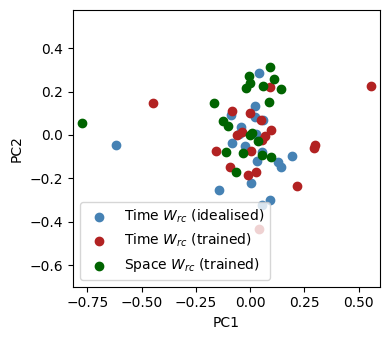

In [ ]:
# Plot PCA 2D
plt.figure(figsize=(4, 3.5))
plt.scatter(Z_th[:, 0], Z_th[:, 1], color='steelblue', label=r'Time $W_{rc}$ (idealised)')
plt.scatter(Z_tr[:, 0], Z_tr[:, 1], color='firebrick', label=r'Time $W_{rc}$ (trained)')
plt.scatter(Z_sp[:, 0], Z_sp[:, 1], color='darkgreen', label=r'Space $W_{rc}$ (trained)')

for i in range(k):
    plt.text(Z_th[i, 0], Z_th[i, 1], str(i), fontsize=8)
    plt.text(Z_tr[i, 0], Z_tr[i, 1], str(i), fontsize=8)
    plt.text(Z_sp[i, 0], Z_sp[i, 1], str(i), fontsize=8)

plt.xlabel('PC1')
plt.ylabel('PC2')
# plt.title('First k modes projected to 2D space (PCA)')
plt.axis('equal')
plt.legend(loc='best')
plt.tight_layout()
# plt.savefig('mode_pca_comparison.png', transparent=True, dpi=500)


(1536, 20)


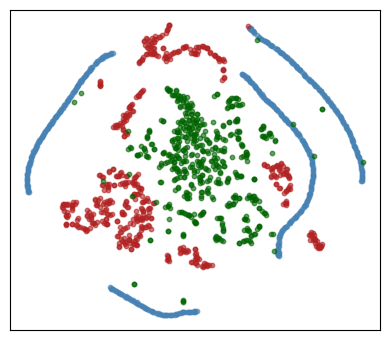

In [22]:
from sklearn.manifold import TSNE
U_tr_k = U_tr[:, :k]   # (N, k)
U_th_k = U_th[:, :k]   # (N, k)
U_sp_k = U_sp[:, :k]   # (N, k)
U_all = np.concatenate([U_tr_k, U_th_k, U_sp_k]) 
print(U_all.shape)
tsne = TSNE(n_components=2, perplexity=10, random_state=0)
U_tsne = tsne.fit_transform(U_all)

N = 512
Z_tr = U_tsne[:N]
Z_th = U_tsne[N:2*N]
Z_sp = U_tsne[2*N:]

# Plot
plt.figure(figsize=(4, 3.5))
plt.scatter(Z_th[:, 0], Z_th[:, 1], color='steelblue', label=r'Time $W_{rc}$ (idealised)', alpha=0.6, s=10)
plt.scatter(Z_tr[:, 0], Z_tr[:, 1], color='firebrick', label=r'Time $W_{rc}$ (trained)', alpha=0.6, s=10)
plt.scatter(Z_sp[:, 0], Z_sp[:, 1], color='darkgreen', label=r'Space $W_{rc}$ (trained)', alpha=0.6, s=10)
# plt.legend()
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.savefig('tsne.png', transparent=True, dpi=500)